In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [46]:
df = pd.read_csv("loan_approval_data.csv")

In [47]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

handle missing values


In [48]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["float64"]).columns

In [49]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [50]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

num_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols]=num_imp.fit_transform(df[categorical_cols])

exploratory data analysis

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

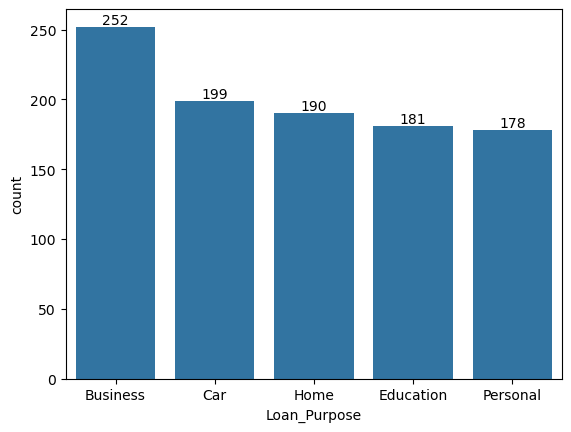

In [51]:
loan_pur = df["Loan_Purpose"].value_counts()
ax = sns.barplot(loan_pur)
ax.bar_label(ax.containers[0])

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

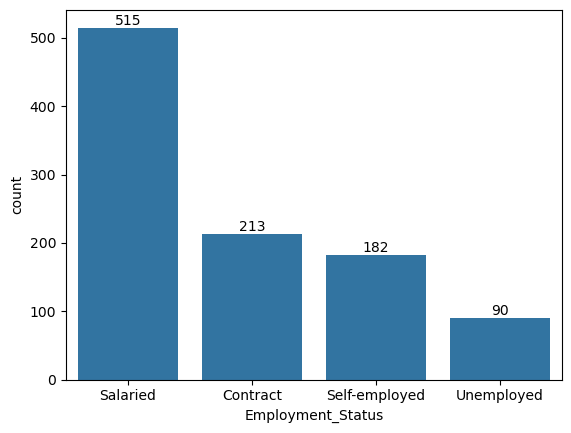

In [52]:
Employment_Sta = df["Employment_Status"].value_counts()
ax = sns.barplot(Employment_Sta)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

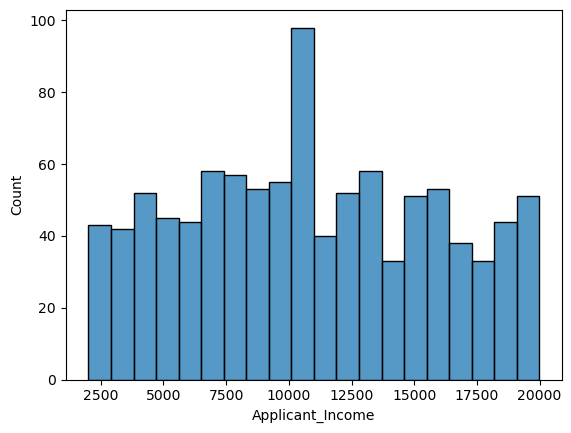

In [53]:
sns.histplot(
    data= df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

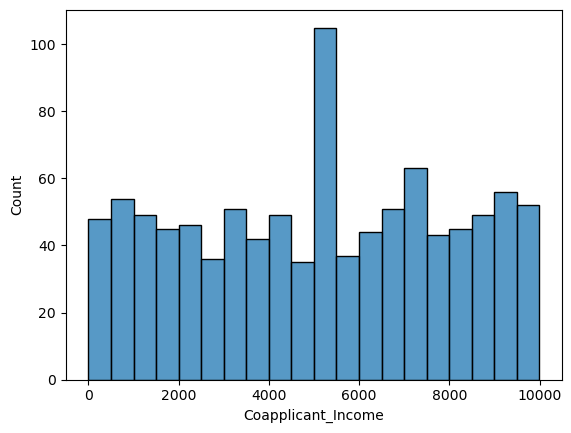

In [54]:
sns.histplot(
    data= df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

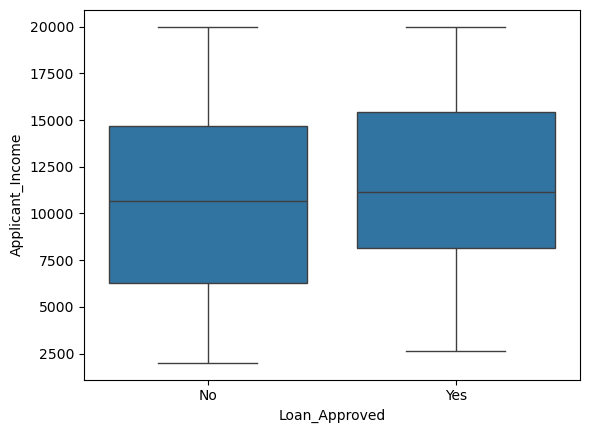

In [55]:
# outliers-box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

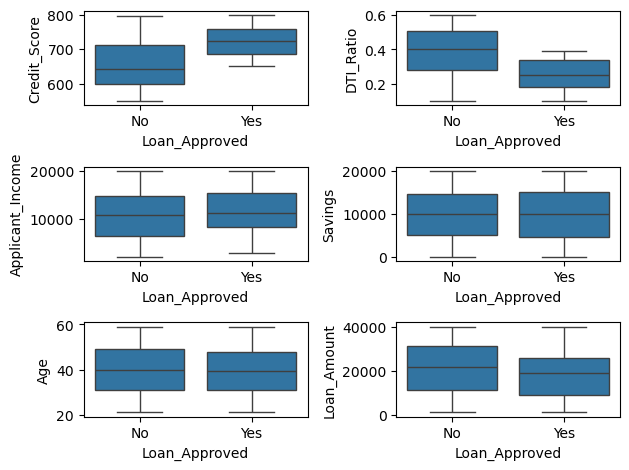

In [56]:
fig,axes = plt.subplots(3,2)
sns.boxplot(ax=axes[0,0],data=df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,1],data=df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[1,1],data=df, x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[2,0],data=df, x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[2,1],data=df, x="Loan_Approved",y="Loan_Amount")

plt.tight_layout()



In [57]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

<Axes: xlabel='Credit_Score', ylabel='Count'>

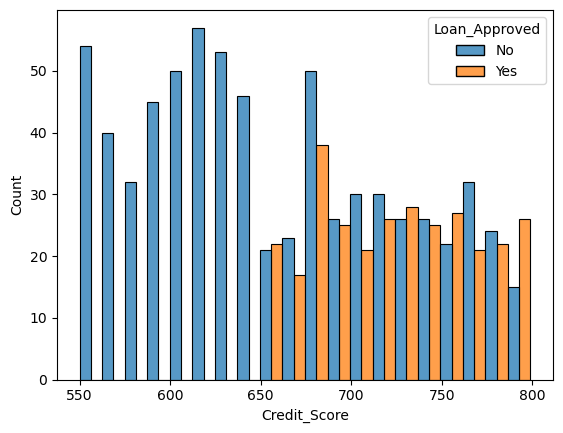

In [58]:
# credit score with loan approved

sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

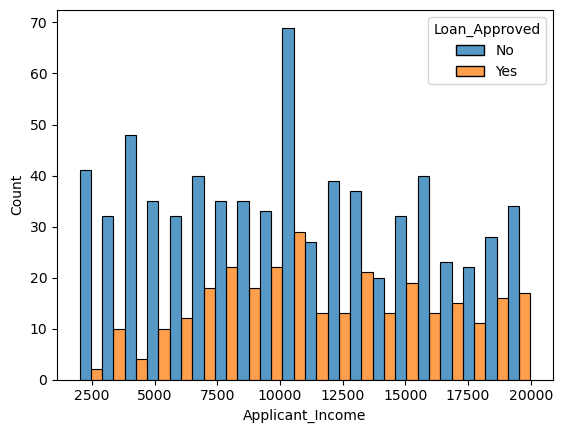

In [59]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

In [60]:
df = df.drop("Applicant_ID",axis=1)

In [61]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


encoding techniques


In [62]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [63]:
cols = ["Employment_Status","Employer_Category","Loan_Purpose","Property_Area","Gender","Marital_Status"]

from sklearn.preprocessing import OneHotEncoder ,LabelEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# ohe = OneHotEncoder(handle_unknown="ignore",drop="first", sparse_output=False)
# ohe.fit(df[cols])



In [64]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [65]:

ohe = OneHotEncoder(handle_unknown="ignore",drop="first", sparse_output=False)
encoded = ohe.fit_transform(df[cols])

In [66]:
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_Private,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Marital_Status_Single
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

correlation heatmap


In [68]:
num_cols = df.select_dtypes(include="number")

corr_matrix = num_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_Private,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Marital_Status_Single
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,-0.044639,-0.011995,-0.083398,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,0.010057
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.004312,-0.047929,-0.020148,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.011431
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.012960,0.072462,-0.025521,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,0.009162
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,0.030197,-0.054147,-0.043685,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.011410
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,-0.000049,-0.046087,-0.030142,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,0.056176
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.019306,0.045391,-0.025228,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,0.018010
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,-0.003506,0.026018,-0.020907,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.014850
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,-0.030208,0.027178,-0.009133,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.004131
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,-0.014480,-0.009655,0.031112,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.018450
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,0.013923,-0.026566,-0.006788,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.004683


<Axes: >

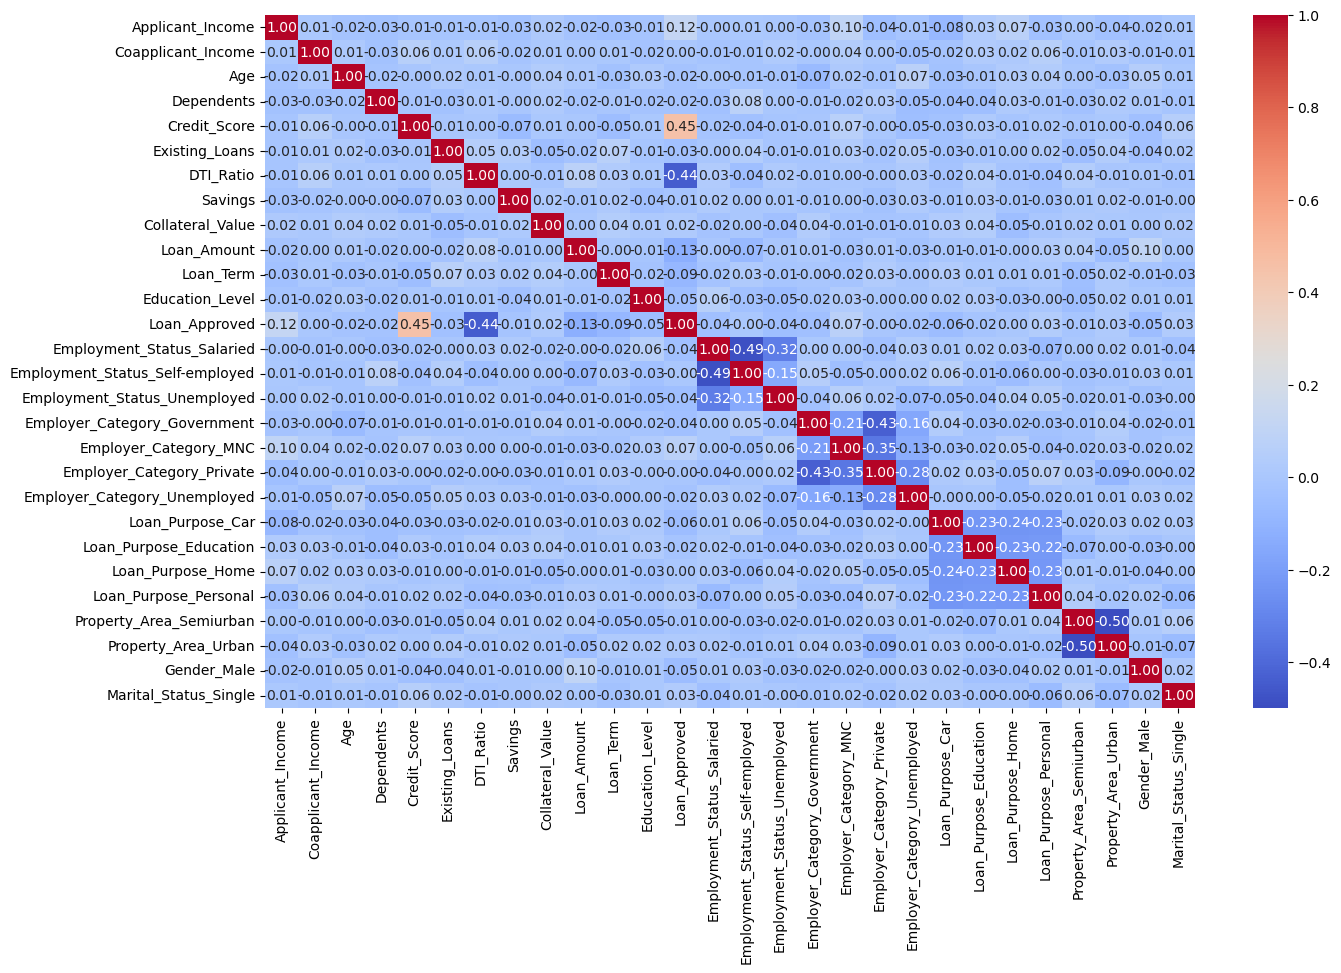

In [69]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
plt.figure(figsize=(15,9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


training ,and feature scaling

In [70]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,accuracy_score,confusion_matrix,f1_score,recall_score
neigh = KNeighborsClassifier(n_neighbors=13)
neigh.fit(X_train_scaled, y_train)

y_pred = neigh.predict(X_test_scaled)

print("precision score",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("recall score",recall_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))

precision score 0.7317073170731707
accuracy score 0.79
recall score 0.4918032786885246
f1 score 0.5882352941176471


In [74]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("precision score",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("recall score",recall_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))

precision score 0.7833333333333333
accuracy score 0.865
recall score 0.7704918032786885
f1 score 0.7768595041322314


In [75]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
y_pred = gnb.fit(X_train_scaled, y_train)

y_pred = gnb.predict(X_test_scaled)
print("precision score",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("recall score",recall_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))

precision score 0.8035714285714286
accuracy score 0.865
recall score 0.7377049180327869
f1 score 0.7692307692307693


feature engineering


In [76]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

X = df.drop(["Loan_Approved","DTI_Ratio","Credit_Score"],axis=1)
y = df["Loan_Approved"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,accuracy_score,confusion_matrix,f1_score,recall_score
neigh = KNeighborsClassifier(n_neighbors=13)
neigh.fit(X_train_scaled, y_train)

y_pred = neigh.predict(X_test_scaled)

print("precision score",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("recall score",recall_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))

precision score 0.7368421052631579
accuracy score 0.785
recall score 0.45901639344262296
f1 score 0.5656565656565656


In [78]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("precision score",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("recall score",recall_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))

precision score 0.7903225806451613
accuracy score 0.875
recall score 0.8032786885245902
f1 score 0.7967479674796748


In [79]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
y_pred = gnb.fit(X_train_scaled, y_train)

y_pred = gnb.predict(X_test_scaled)
print("precision score",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("recall score",recall_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))

precision score 0.7833333333333333
accuracy score 0.865
recall score 0.7704918032786885
f1 score 0.7768595041322314
